# UCI Heart Disease Detection

## Dataset Overview
- 920 patient records
- Mix of numerical and categorical clinical features
- Target class fairly balanced (55% positive)

## Exploratory Data Analysis

In [1]:
import pandas as pd

heart = pd.read_csv("heart_disease_uci.csv")
heart.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [2]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [3]:
heart.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [4]:
heart.describe(include=["O"])

,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [5]:
heart = heart.drop("id", axis=1)

In [6]:
heart["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

### I see there is more than two values for the target, which classifies the severity of the disease. I will encode this, as I want to only detect a 0 or 1 for heart disease.

In [7]:
heart["num"] = (heart["num"] > 0).astype(int) # Assigns 1 to the positive class and 0 to the negative class
heart["num"].value_counts(normalize=True)

num
1    0.553261
0    0.446739
Name: proportion, dtype: float64

### The target class is pretty evenly distrubted so I won't need to do any sampling techniques later.

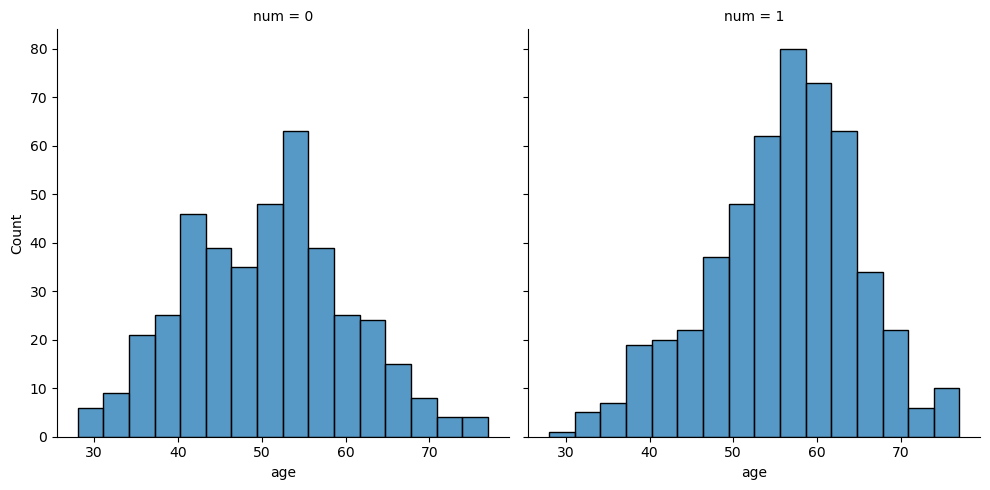

In [8]:
import seaborn as sns

sns.displot(heart, x="age", col="num", binwidth=3, height=5)

In [9]:
heart1 = heart.copy()

In [10]:
heart1["age_cut"] = pd.qcut(heart["age"], 5)

In [11]:
heart1.groupby("age_cut", as_index=False, observed=True)["num"].mean()

,age_cut,num
0,"(27.999, 45.0]",0.311224
1,"(45.0, 52.0]",0.510417
2,"(52.0, 57.0]",0.562189
3,"(57.0, 62.0]",0.721591
4,"(62.0, 77.0]",0.709677


In [12]:
heart1.groupby("sex", as_index=False)["num"].mean()

,sex,num
0,Female,0.257732
1,Male,0.632231


In [13]:
heart1.groupby("dataset", as_index=False)["num"].mean()

,dataset,num
0,Cleveland,0.457237
1,Hungary,0.361775
2,Switzerland,0.934959
3,VA Long Beach,0.745000


In [14]:
heart1.groupby("cp", as_index=False)["num"].mean()

,cp,num
0,asymptomatic,0.790323
1,atypical angina,0.137931
2,non-anginal,0.357843
3,typical angina,0.434783


In [15]:
heart1["trestbps_cut"] = pd.qcut(heart1["trestbps"], 5)

In [16]:
heart1.groupby("trestbps_cut", as_index=False, observed=True)["num"].mean()

,trestbps_cut,num
0,"(-0.001, 120.0]",0.484642
1,"(120.0, 125.0]",0.648148
2,"(125.0, 135.0]",0.488889
3,"(135.0, 150.0]",0.571429
4,"(150.0, 200.0]",0.692308


In [17]:
heart1["chol_cut"] = pd.qcut(heart1["chol"], 5)

In [18]:
heart1.groupby("chol_cut", as_index=False, observed=True)["num"].mean()

,chol_cut,num
0,"(-0.001, 130.6]",0.865169
1,"(130.6, 211.0]",0.392473
2,"(211.0, 240.0]",0.457143
3,"(240.0, 277.0]",0.505682
4,"(277.0, 603.0]",0.582857


In [19]:
heart1.groupby("fbs", as_index=False)["num"].mean()

,fbs,num
0,False,0.489884
1,True,0.681159


In [20]:
heart1.groupby("restecg", as_index=False)["num"].mean()

,restecg,num
0,lv hypertrophy,0.563830
1,normal,0.513612
2,st-t abnormality,0.659218


In [21]:
heart1["thalch_cut"] = pd.qcut(heart1["thalch"], 5)

In [22]:
heart1.groupby("thalch_cut", as_index=False, observed=True)["num"].mean()

,thalch_cut,num
0,"(59.999, 115.0]",0.785714
1,"(115.0, 130.0]",0.724138
2,"(130.0, 146.0]",0.538922
3,"(146.0, 161.0]",0.433526
4,"(161.0, 202.0]",0.236686


In [23]:
heart1["max_hr_gap"] = 220 - heart1["age"] - heart1["thalch"]

In [24]:
heart1["max_hr_gap_cut"] = pd.qcut(heart1["max_hr_gap"], 5)

In [25]:
heart1.groupby("max_hr_gap_cut", as_index=False, observed=True)["num"].mean()

,max_hr_gap_cut,num
0,"(-29.001, 6.8]",0.312139
1,"(6.8, 21.0]",0.472527
2,"(21.0, 35.0]",0.535294
3,"(35.0, 51.0]",0.686391
4,"(51.0, 109.0]",0.742690


In [26]:
heart1.groupby("exang", as_index=False)["num"].mean()

,exang,num
0,False,0.363636
1,True,0.836795


In [27]:
heart1["oldpeak_cut"] = pd.cut(heart1["oldpeak"], 5)

In [28]:
heart1.groupby("oldpeak_cut", as_index=False, observed=True)["num"].mean()

,oldpeak_cut,num
0,"(-2.609, -0.84]",0.857143
1,"(-0.84, 0.92]",0.363830
2,"(0.92, 2.68]",0.731861
3,"(2.68, 4.44]",0.918033
4,"(4.44, 6.2]",1.000000


In [29]:
heart1.groupby("slope", as_index=False, observed=True)["num"].mean()

,slope,num
0,downsloping,0.777778
1,flat,0.771014
2,upsloping,0.384236


In [30]:
heart1.groupby("ca", as_index=False, observed=True)["num"].mean()

,ca,num
0,0.0,0.265193
1,1.0,0.686567
2,2.0,0.804878
3,3.0,0.850000


In [31]:
heart1.groupby("thal", as_index=False, observed=True)["num"].mean()

,thal,num
0,fixed defect,0.760870
1,normal,0.295918
2,reversable defect,0.802083


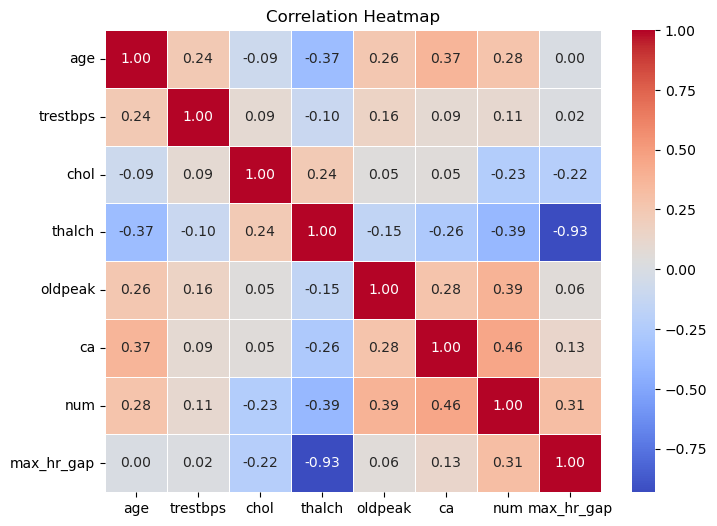

In [32]:
import matplotlib.pyplot as plt

matrix = heart1.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


## Key EDA Insights

- Heart disease prevalence increases with age
- Males show substantially higher disease rates than females
- Exercise-induced angina (`exang`) and asymptomatic chest pain are strong indicators
- Lower maximum heart rate (`thalch`) is associated with higher disease probability
- Number of vessels (`ca`) and thalassemia (`thal`) are highly predictive features

## Pipelines

In [34]:
from sklearn.model_selection import train_test_split

X = heart.drop("num", axis=1)
y = heart["num"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [35]:
# I removed this method, as the new feature did not have a meaningful 
# impact on cross-validation score and to reduce model complexity

# from sklearn.base import BaseEstimator, TransformerMixin

# class AddNewFeature(BaseEstimator, TransformerMixin):
#    def fit(self, X, y=None):
#        return self

#    def transform(self, X):
#        X = X.copy()
#        X["max_hr_gap"] = 220 - X["age"] - X["thalch"]
#        return X

In [36]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"] # "max_hr_gap" was removed

In [37]:
cat_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"]

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

In [39]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("one-hot", OneHotEncoder(handle_unknown="ignore"))
])

In [40]:
from sklearn.compose import ColumnTransformer

col_transformer = ColumnTransformer(transformers=[
    ("num_pipeline", num_pipeline, num_cols),
    ("cat_pipeline", cat_pipeline, cat_cols),
], 
    remainder = "drop",
    n_jobs = -1
)

## Model Training

### Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

lr = LogisticRegression(random_state=42)

In [42]:
param_grid = {
    "C" : [4, 5, 6, 7]
}

In [43]:
CV_lr = GridSearchCV(estimator=lr, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [44]:
pipefinallr = make_pipeline(col_transformer, CV_lr)
pipefinallr.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=LogisticRegression(random_state=42),
                              n_jobs=-1, param_grid={'C': [4, 5, 6, 7]}))])

In [45]:
print("Best Score:", CV_lr.best_score_)
print("Best Params:", CV_lr.best_params_)

Best Score: 0.8287460930318075
Best Params: {'C': 5}


In [46]:
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report

y_pred = pipefinallr.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred)) 

Confusion Matrix:
 [[63 19]
 [12 90]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.77      0.80        82
           1       0.83      0.88      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



### Decision Tree 

In [47]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)

In [48]:
param_grid = {
    "criterion" : ["entropy"],
    "splitter" : ["random"],
    "max_depth" : [8, 9, 10, 11, 12],
    "min_samples_split" : [7, 8, 9, 10],
    "min_samples_leaf" : [1, 2, 3],
    "max_features" : [7, 8, 9, 10, 11]
}

In [49]:
CV_dtc = GridSearchCV(estimator=dtc, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [50]:
pipefinaldtc = make_pipeline(col_transformer, CV_dtc)
pipefinaldtc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_...
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=DecisionTreeClassifier(random_state=42),
                              n_jobs=-1,
                              param_grid={'criterion': ['entropy'],
                                          'max_depth': [8, 9, 10, 11, 12],
                                          'max_features': [7, 8, 9, 10, 11],
                                          'min_samples_leaf': [1, 2, 3],
                                          'min_samples_split': [7, 8, 9, 10],
                                          'splitter': ['random']}))])

In [51]:
print("Best Score:", CV_dtc.best_score_)
print("Best Params:", CV_dtc.best_params_)

Best Score: 0.7948244162529876
Best Params: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 9, 'min_samples_leaf': 3, 'min_samples_split': 10, 'splitter': 'random'}


In [52]:
y_pred = pipefinaldtc.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[65 17]
 [20 82]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.78        82
           1       0.83      0.80      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



### Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)

In [54]:
param_grid = {
    "n_estimators" : [395, 400, 405],
    "criterion" : ["gini"],
    "max_depth" : [10, 11, 12],
    "min_samples_split" : [10, 11, 12],
    "min_samples_leaf" : [1, 2, 3],
    "max_features" : [1, 2]
}

In [55]:
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [56]:
pipefinalrfc = make_pipeline(col_transformer, CV_rfc)
pipefinalrfc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_...
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=RandomForestClassifier(random_state=42),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini'],
                                          'max_depth': [10, 11, 12],
                                          'max_features': [1, 2],
                                          'min_samples_leaf': [1, 2, 3],
                                          'min_samples_split': [10, 11, 12],
                                          'n_estimators': [395, 400, 405]}))])

In [57]:
print("Best Score:", CV_rfc.best_score_)
print("Best Params:", CV_rfc.best_params_)

Best Score: 0.8437396580253722
Best Params: {'criterion': 'gini', 'max_depth': 11, 'max_features': 1, 'min_samples_leaf': 2, 'min_samples_split': 11, 'n_estimators': 400}


In [58]:
y_pred = pipefinalrfc.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[63 19]
 [ 7 95]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.77      0.83        82
           1       0.83      0.93      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



### KNN

In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn =  KNeighborsClassifier()

In [60]:
param_grid = {
    "n_neighbors" : [4, 5, 6, 7, 8],
    "weights" : ["uniform", "distance"],
    "algorithm" : ["auto", "ball_tree", "kd_tree", "brute"]
}

In [61]:
CV_knn = GridSearchCV(estimator=knn, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [62]:
pipefinalknn = make_pipeline(col_transformer, CV_knn)
pipefinalknn.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=KNeighborsClassifier(), n_jobs=-1,
                              param_grid={'algorithm': ['auto', 'ball_tree',
                                                        'kd_tree', 'brute'],
                                          'n_neighbors': [4, 5, 6, 7, 8],
                                          'weights': ['uniform',
                                                      'distance']}))])

In [63]:
print("Best Score:", CV_knn.best_score_)
print("Best Params:", CV_knn.best_params_)

Best Score: 0.8301434087148373
Best Params: {'algorithm': 'auto', 'n_neighbors': 7, 'weights': 'distance'}


In [64]:
y_pred = pipefinalknn.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[65 17]
 [11 91]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



### SVC

In [65]:
from sklearn.svm import SVC

svc = SVC(random_state=42)

In [66]:
param_grid = {
    "C" : [6, 7, 8, 9],
    "kernel" : ["rbf"],
    "gamma" : ["auto"]
}

In [67]:
CV_svc = GridSearchCV(estimator=svc, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [68]:
pipefinalsvc = make_pipeline(col_transformer, CV_svc)
pipefinalsvc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=SVC(random_state=42), n_jobs=-1,
                              param_grid={'C': [6, 7, 8, 9], 'gamma': ['auto'],
                                          'kernel': ['rbf']}))])

In [69]:
print("Best Score:", CV_svc.best_score_)
print("Best Params:", CV_svc.best_params_)

Best Score: 0.8396580253723112
Best Params: {'C': 8, 'gamma': 'auto', 'kernel': 'rbf'}


In [70]:
y_pred = pipefinalsvc.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[63 19]
 [ 9 93]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82        82
           1       0.83      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



### Gaussian NB

In [71]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

In [72]:
param_grid = {
    "var_smoothing" : [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [73]:
CV_gnb = GridSearchCV(estimator=gnb, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [74]:
pipefinalgnb = make_pipeline(col_transformer, CV_gnb)
pipefinalgnb.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=GaussianNB(), n_jobs=-1,
                              param_grid={'var_smoothing': [1e-11, 1e-10, 1e-09,
                                                            1e-08, 1e-07]}))])

In [75]:
print("Best Score:", CV_gnb.best_score_)
print("Best Params:", CV_gnb.best_params_)

Best Score: 0.8070601213458357
Best Params: {'var_smoothing': 1e-11}


In [76]:
y_pred = pipefinalgnb.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[69 13]
 [11 91]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85        82
           1       0.88      0.89      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



### AdaBoost

In [77]:
from sklearn.ensemble import AdaBoostClassifier

dtc_abc = DecisionTreeClassifier(
    criterion="entropy",
    splitter="random",
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=2,
    max_features=9,
    random_state=42
)

abc = AdaBoostClassifier(dtc_abc, random_state=42)

In [78]:
param_grid = {
    "n_estimators" : [100, 105, 110],
    "learning_rate" : [0.12, 0.13, 0.14]
}

In [79]:
CV_abc = GridSearchCV(estimator=abc, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [80]:
pipefinalabc = make_pipeline(col_transformer, CV_abc)
pipefinalabc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_...
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(criterion='entropy',
                                                                                            max_depth=10,
                                                                                            max_features=9,
                                                                                            min_samples_leaf=2,
                                                                                            min_samples_split=8,
                                                                                            random_state=42,
                                                                                            splitter='random'),
                                                           random_state=42),
                              n_jobs=-1,
                              param_grid={'learning_rate': [0.12, 0.13, 0.14],
                                          'n_estimators': [100, 105, 110]}))])

In [81]:
print("Best Score:", CV_abc.best_score_)
print("Best Params:", CV_abc.best_params_)

Best Score: 0.8219617576760434
Best Params: {'learning_rate': 0.14, 'n_estimators': 110}


In [82]:
y_pred = pipefinalabc.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[62 20]
 [14 88]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.78        82
           1       0.81      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184



### Gradient Boosting

In [83]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=42)

In [84]:
param_grid = {
    "loss" : ["log_loss"],
    "learning_rate" : [0.048, 0.05, 0.052], 
    "n_estimators" : [280, 285, 290],
    "criterion" : ["friedman_mse"]
}

In [85]:
CV_gbc = GridSearchCV(estimator=gbc, param_grid=param_grid, n_jobs=-1, cv=StratifiedKFold(n_splits=5))

In [86]:
pipefinalgbc = make_pipeline(col_transformer, CV_gbc)
pipefinalgbc.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(n_jobs=-1,
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalch', 'oldpeak', 'ca']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('one-hot',
                                                                   OneHotEncoder(handle_...
                                                  ['sex', 'dataset', 'cp',
                                                   'fbs', 'restecg', 'exang',
                                                   'slope', 'thal'])])),
                ('gridsearchcv',
                 GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
                              estimator=GradientBoostingClassifier(random_state=42),
                              n_jobs=-1,
                              param_grid={'criterion': ['friedman_mse'],
                                          'learning_rate': [0.048, 0.05, 0.052],
                                          'loss': ['log_loss'],
                                          'n_estimators': [280, 285, 290]}))])

In [87]:
print("Best Score:", CV_gbc.best_score_)
print("Best Params:", CV_gbc.best_params_)

Best Score: 0.8301342158485017
Best Params: {'criterion': 'friedman_mse', 'learning_rate': 0.05, 'loss': 'log_loss', 'n_estimators': 290}


In [88]:
y_pred = pipefinalgbc.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[65 17]
 [10 92]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.79      0.83        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



## Model Evaluation

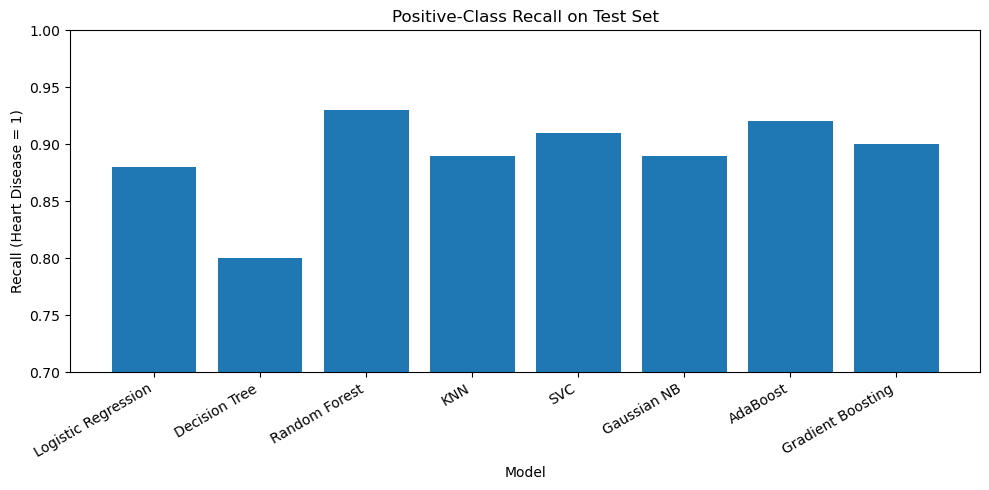

In [89]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "KNN",
    "SVC",
    "Gaussian NB",
    "AdaBoost",
    "Gradient Boosting"
]

# Recall for positive class (heart disease = 1)
recall_pos = [
    0.88,  # Logistic Regression
    0.80,  # Decision Tree
    0.93,  # Random Forest
    0.89,  # KNN
    0.91,  # SVC
    0.89,  # Gaussian NB
    0.92,  # AdaBoost
    0.90   # Gradient Boosting
]

plt.figure(figsize=(10, 5))
plt.bar(models, recall_pos)
plt.ylim(0.7, 1)
plt.ylabel("Recall (Heart Disease = 1)")
plt.xlabel("Model")
plt.title("Positive-Class Recall on Test Set")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()